In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler as sc
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
from prophet import Prophet
# model metrics
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [2]:
df = pd.read_csv('afg_geocoded_imputed.csv')
df

,Semester,World region,Country,Administrative Division,Disease,Serotype/Subtype/Genotype,Animal Category,Species,Event_id,Measuring units,New outbreaks,Susceptible,Cases,Killed and disposed of,Deaths,Latitude,Longitude,Year
0,Jul-Dec 2009,Americas,United States of America,Indiana,Influenza A virus (Inf. with),-,Domestic,Swine,753,Animal,1.0,3000.0,1.0,0.0,0.0,40.327013,-86.174693,2009.0
1,Jul-Dec 2009,Americas,United States of America,Virginia,Influenza A virus (Inf. with),-,Domestic,Birds,773,Animal,1.0,3270.0,1.2,0.0,0.0,37.123224,-78.492772,2009.0
2,Jul-Dec 2009,Asia,China,Beijing,Influenza A virus (Inf. with),-,Domestic,Dogs,765,Animal,1.0,52.0,2.0,0.0,0.0,40.190632,116.412144,2009.0
3,Jul-Dec 2009,Asia,China,Heilongjiang,Influenza A virus (Inf. with),-,Domestic,Swine,765,Animal,1.0,60.0,4.0,0.0,0.0,48.000005,127.999992,2009.0
4,Jul-Dec 2009,Asia,Thailand,Saraburi,Influenza A virus (Inf. with),-,Domestic,Swine,786,Animal,1.0,680.0,34.0,0.0,0.0,14.624056,100.860102,2009.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1479,Jan-Jun 2025,Europe,Poland,Olszanica,Influenza A viruses of high pathogenicity (Inf...,H5N1,Domestic,Birds,4063,Animal,2.0,44.0,44.0,26.0,18.0,52.860002,23.085551,2025.0
1480,Jan-Jun 2025,Europe,Poland,Piecki,Influenza A viruses of high pathogenicity (Inf...,H5N1,Domestic,Birds,4063,Animal,1.0,18.0,18.0,4.0,14.0,53.749179,21.341220,2025.0
1481,Jan-Jun 2025,Europe,Poland,Puławy,Influenza A viruses of high pathogenicity (Inf...,H5N1,Wild,Mute Swan,4063,Animal,1.0,3.0,1.0,0.2,1.0,51.426260,21.985301,2025.0
1482,Jan-Jun 2025,Europe,Poland,Skępe,Influenza A viruses of high pathogenicity (Inf...,H5N1,Wild,Mute Swan,4063,Animal,1.0,4.8,2.0,0.2,2.0,52.867156,19.346520,2025.0


In [3]:
df['Serotype/Subtype/Genotype'] = df['Serotype/Subtype/Genotype'].replace("-", "unknown")
df['Serotype/Subtype/Genotype'] = df['Serotype/Subtype/Genotype'].replace("not typed", "unknown")

In [4]:
# find numeric and categorical features
df = df[df['Semester']!= 'Jan-Jun 2022']
df = pd.get_dummies(df)
y = df['Cases']
X = df.drop('Cases', axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns


In [5]:
pca = PCA(n_components=10)

x_train = pca.fit_transform(X_train)
x_test = pca.transform(X_test)

explained_variance = pca.explained_variance_ratio_

explained_variance_ratio = pca.explained_variance_ratio_
for indx, evr in enumerate(explained_variance_ratio):
    print(f"PC{indx+1}: {evr:.2f}")

PC1: 0.97
PC2: 0.02
PC3: 0.01
PC4: 0.00
PC5: 0.00
PC6: 0.00
PC7: 0.00
PC8: 0.00
PC9: 0.00
PC10: 0.00


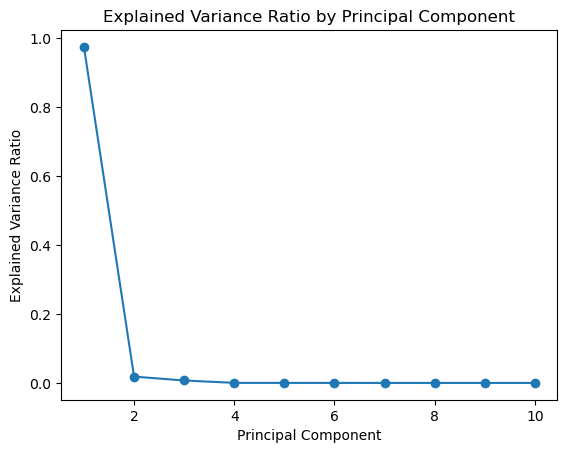

In [6]:
fig, ax = plt.subplots()
# set x and y values
x = np.arange(1, len(explained_variance_ratio) + 1)
y = explained_variance_ratio
# plot
ax.plot(x, y, marker='o')
# set label and title
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

In [7]:
feature_names = X_train.columns
# Accessing the component weights
component_weights = pca.components_
#print("Component Weights:\n", component_weights)
# Create a mapping between component weights and feature names
feature_weights_mapping = {}
for i, component in enumerate(component_weights):
    component_feature_weights = zip(feature_names, component)
    feature_weights_mapping[f"Component {i+1}"] = sorted(
      component_feature_weights, key=lambda x: abs(x[1]), reverse=True)
    
# Accessing feature names contributing to Component 1
print("Feature names contributing to Component 1:")
for feature, weight in feature_weights_mapping["Component 1"]:
    print(f"{feature}: {weight}")

# Accessing feature names contributing to Component 2
print("Feature names contributing to Component 2:")
for feature, weight in feature_weights_mapping["Component 2"]:
    print(f"{feature}: {weight}")

Feature names contributing to Component 1:
Susceptible: 0.787969728783995
Killed and disposed of: 0.587790347246298
Deaths: 0.18251650644445155
Longitude: -0.012368929221128332
New outbreaks: 0.01175319523611762
Latitude: 0.0016590551201202226
Administrative Division_United States of America: 0.00011873454886800761
Country_United States of America: 9.93158891694452e-05
Year: 9.36876198033042e-05
World region_Americas: 8.878188373451659e-05
World region_Europe: -5.874939798786628e-05
Country_Poland: -5.874939798786628e-05
Semester_Jul-Dec 2022: 4.385679429098151e-05
Serotype/Subtype/Genotype_H5N1: 3.4678879016170605e-05
Event_id_-: 3.166755377346856e-05
World region_Africa: -2.5436538188588094e-05
Country_South Africa: -2.5436538188588094e-05
Serotype/Subtype/Genotype_H5N8: -2.4430025352945893e-05
Species_unknown: -2.3000744887059593e-05
Measuring units_-: -2.3000744887059593e-05
Measuring units_Animal: 2.3000744887059593e-05
Animal Category_Wild: 2.247334193478736e-05
Semester_Jul-Dec 

In [8]:
df.corr()

,New outbreaks,Susceptible,Cases,Killed and disposed of,Deaths,Latitude,Longitude,Year,Semester_Jan-Jun 2017,Semester_Jan-Jun 2018,...,Event_id_5755,Event_id_6015,Event_id_6270,Event_id_703,Event_id_753,Event_id_765,Event_id_773,Event_id_786,Measuring units_-,Measuring units_Animal
New outbreaks,1.000000,0.849800,-0.021119,0.839357,0.645431,0.133248,-0.573931,0.039086,-0.080955,-0.054665,...,-0.021222,-0.022005,-0.015554,-0.015554,-0.015554,-0.022005,-0.015554,-0.015554,-0.217633,0.217633
Susceptible,0.849800,1.000000,0.224424,0.929197,0.850650,0.145118,-0.622312,0.111967,-0.097825,-0.106653,...,-0.024617,-0.011045,-0.013818,0.000753,0.010561,-0.023962,0.013082,-0.011109,-0.213183,0.213183
Cases,-0.021119,0.224424,1.000000,-0.011782,0.671513,-0.061203,0.084126,-0.042503,0.011564,0.024192,...,-0.002942,-0.001870,-0.000523,0.001853,-0.002202,-0.003000,-0.002194,-0.000850,0.012200,-0.012200
Killed and disposed of,0.839357,0.929197,-0.011782,1.000000,0.717417,0.225369,-0.694359,0.180810,-0.094006,-0.111055,...,-0.023635,-0.005240,-0.012237,-0.016739,-0.016739,-0.023681,-0.016739,-0.016739,-0.247774,0.247774
Deaths,0.645431,0.850650,0.671513,0.717417,1.000000,0.123725,-0.453198,0.086255,-0.065622,-0.057460,...,-0.019385,-0.018695,-0.012604,-0.013824,-0.013824,-0.019558,-0.013824,-0.013824,-0.170481,0.170481
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Event_id_765,-0.022005,-0.023962,-0.003000,-0.023681,-0.019558,0.020842,0.090410,-0.231551,-0.006615,-0.007050,...,-0.001497,-0.001497,-0.001058,-0.001058,-0.001058,1.000000,-0.001058,-0.001058,-0.017350,0.017350
Event_id_773,-0.015554,0.013082,-0.002194,-0.016739,-0.013824,0.008784,-0.019813,-0.163670,-0.004676,-0.004983,...,-0.001058,-0.001058,-0.000748,-0.000748,-0.000748,-0.001058,1.000000,-0.000748,-0.012264,0.012264
Event_id_786,-0.015554,-0.011109,-0.000850,-0.016739,-0.013824,-0.010412,0.055001,-0.163670,-0.004676,-0.004983,...,-0.001058,-0.001058,-0.000748,-0.000748,-0.000748,-0.001058,-0.000748,1.000000,-0.012264,0.012264
Measuring units_-,-0.217633,-0.213183,0.012200,-0.247774,-0.170481,0.032872,0.343855,-0.078271,0.079998,-0.013607,...,-0.017350,-0.017350,-0.012264,-0.012264,-0.012264,-0.017350,-0.012264,-0.012264,1.000000,-1.000000


Time Series

In [9]:
import warnings
warnings.filterwarnings('ignore')


semester_cols = [col for col in df.columns if col.startswith('Semester_')]

def semester_col_to_date(col_name):
    sem, year = col_name.replace('Semester_', '').split()
    if sem == 'Jan-Jun':
        return pd.to_datetime(f'{year}-04-01')
    else:
        return pd.to_datetime(f'{year}-10-01')

time_data = []
for sem_col in semester_cols:
    date = semester_col_to_date(sem_col)
    cases = df.loc[df[sem_col] == 1, 'Cases'].sum()
    time_data.append({'Date': date, 'Cases': cases})

time_series = (pd.DataFrame(time_data)
               .sort_values('Date')
               .set_index('Date')['Cases'])

start_date = time_series.index.min()
end_date = time_series.index.max()
full_range = pd.date_range(start=start_date, end=end_date, freq='6MS')
time_series = time_series.reindex(full_range).fillna(0)

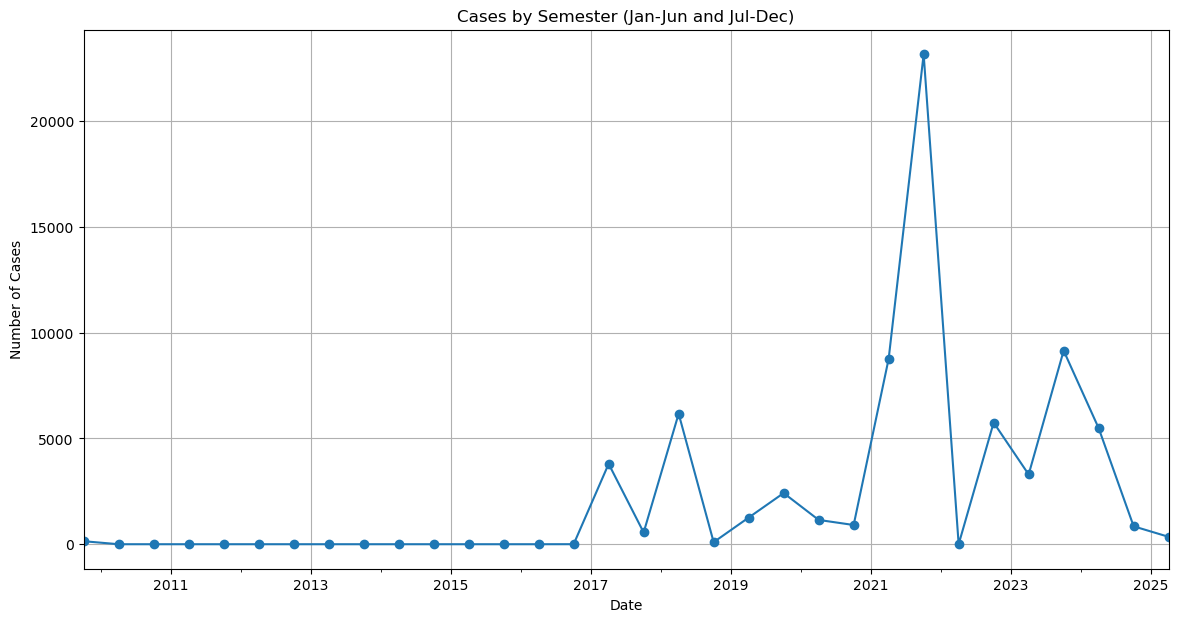

In [10]:
# Plot
plt.figure(figsize=(14, 7))
time_series.plot(title='Cases by Semester (Jan-Jun and Jul-Dec)', marker='o', linestyle='-')
plt.ylabel('Number of Cases')
plt.xlabel('Date')
plt.grid(True)
plt.show()

In [11]:
result = adfuller(time_series)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: 0.4866080435567254
p-value: 0.9844603242990062
Critical Values: {'1%': -3.7883858816542486, '5%': -3.013097747543462, '10%': -2.6463967573696143}


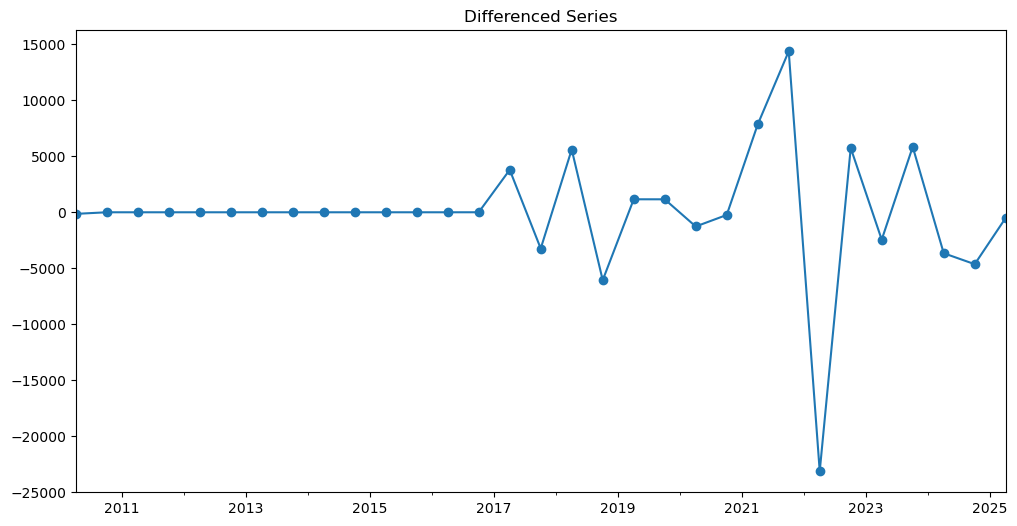

In [12]:
# If p-value > 0.05
if result[1] > 0.05:
    time_series_diff = time_series.diff().dropna()
    plt.figure(figsize=(12, 6))
    time_series_diff.plot(title='Differenced Series', marker='o')
    plt.show()

In [13]:
# Split into train and test
train = time_series[:-4]
test = time_series[-4:]

# Fit model
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 2)

model = SARIMAX(train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit()

print(results.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             Cases   No. Observations:                   28
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 2)   Log Likelihood                -214.020
Date:                           Fri, 25 Apr 2025   AIC                            438.040
Time:                                   14:41:59   BIC                            443.262
Sample:                               10-01-2009   HQIC                           439.173
                                    - 04-01-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0411      1.023      0.040      0.968      -1.963       2.046
ma.L1         -0.9080      0.929     -0.977

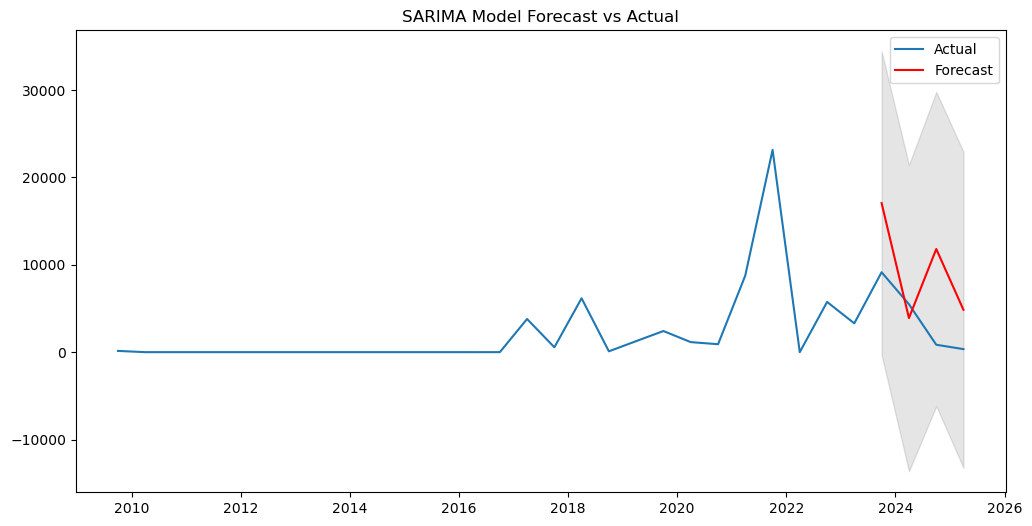

RMSE: 7166.009240786613


In [14]:
# Predictions
pred = results.get_prediction(start=test.index[0], end=test.index[-1], dynamic=False)
pred_ci = pred.conf_int()

# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(time_series, label='Actual')
plt.plot(pred.predicted_mean, label='Forecast', color='red')
plt.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=0.1)
plt.title('SARIMA Model Forecast vs Actual')
plt.legend()
plt.show()

# RMSE
rmse = np.sqrt(mean_squared_error(test, pred.predicted_mean))
print(f'RMSE: {rmse}')

Random Forrest Regressor

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    # ("scaler", StandardScaler()),  # not needed for trees
    ("model", RandomForestRegressor(random_state=42))
])
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5],
}
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="r2")
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("RandomForest Best R²:", grid_search.best_score_)
cv_results = cross_validate(best_model, X, y, cv=5, scoring='r2', return_train_score=True)
print(cv_results['test_score'])

RandomForest Best R²: 0.8378289598025337
[ 0.81937846  0.40220169 -0.14235319  0.97765044  0.95855934]


In [16]:
print("X shape:", X.shape)
print("y shape:", y.shape)

# 1. Basic shape check
print("df shape:", df.shape)

# 2. Create X and y
y = df['Cases']
X = df.drop('Cases', axis=1)

# 3. Print X and y shape
print("X shape:", X.shape)
print("y shape:", y.shape)

# 4. Check if there are any NaNs
print("NaNs in y:", y.isna().sum())
print("NaNs in X:", X.isna().sum().sum())  # total NaNs in X

# 5. Confirm alignment
print("X and y aligned?", len(X) == len(y))


X shape: (1338, 728)
y shape: (10,)
df shape: (1338, 729)
X shape: (1338, 728)
y shape: (1338,)
NaNs in y: 0
NaNs in X: 0
X and y aligned? True


In [ ]:
import folium
from folium.plugins import MarkerCluster

y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

df_test = X_test.copy()
df_test['actual'] = y_test
df_test['predicted'] = y_pred

# --- Create a base map centered on the mean location ---
map_center = [df_test['Latitude'].mean(), df_test['Longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=10)

# --- Create a marker cluster to avoid overlap ---
marker_cluster = MarkerCluster().add_to(m)

# --- Add markers with predicted values ---
for _, row in df_test.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,
        fill=True,
        fill_color='blue',
        color='black',
        fill_opacity=0.7,
        popup=f"Predicted: {row['predicted']:.2f}<br>Actual: {row['actual']:.2f}"
    ).add_to(marker_cluster)

# --- Display the map ---
m


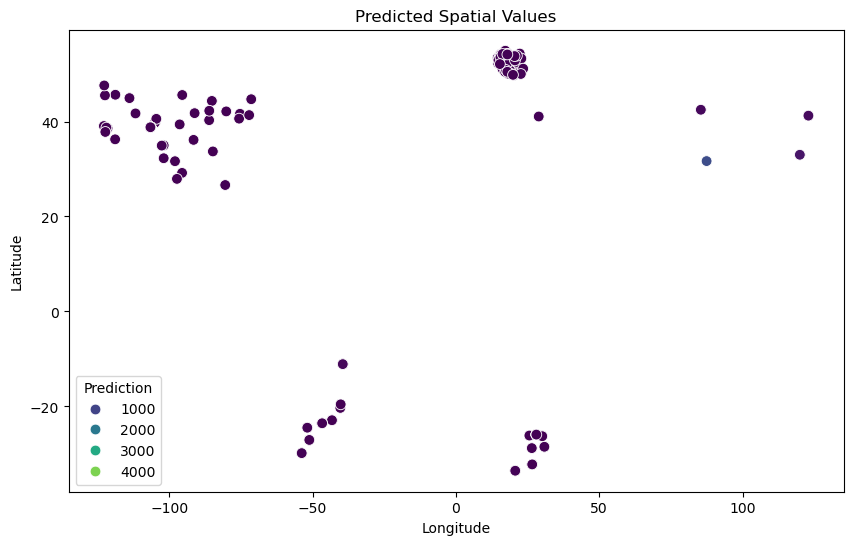

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# --- Optional: Spatial Plot of Predictions ---
df_test = X_test.copy()
df_test['actual'] = y_test
df_test['predicted'] = y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_test, x='Longitude', y='Latitude', hue='predicted', palette='viridis', s=60)
plt.title("Predicted Spatial Values")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Prediction")
plt.show()



Hybrid mode

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import root_mean_squared_error, r2_score

# ---- Step 1: Fit SARIMAX on training target ----
sarimax_model = SARIMAX(y_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarimax_result = sarimax_model.fit(disp=False)

# ---- Step 2: Predict SARIMAX on train & test ----
sarimax_pred_train = sarimax_result.predict(start=y_train.index[0], end=y_train.index[-1])
n_steps = len(y_test)
sarimax_forecast = sarimax_result.get_forecast(steps=n_steps)
sarimax_pred_test = sarimax_forecast.predicted_mean
sarimax_pred_test.index = y_test.index  # Align index with test


# ---- Step 3: Compute residuals ----
sarimax_pred_train = sarimax_pred_train.reindex(y_train.index)
residuals_train = (y_train - sarimax_pred_train).dropna()

# ---- Step 4: Align X_train with residuals ----
X_train_aligned = X_train.loc[residuals_train.index]

# ---- Step 5: Fit Random Forest on residuals ----
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_aligned, residuals_train)

# ---- Step 6: Predict residuals on test data ----
residuals_pred_rf = rf_model.predict(X_test)

# ---- Step 7: Combine predictions ----
sarimax_pred_test = sarimax_pred_test.reindex(y_test.index)

# Drop NaNs from SARIMAX test predictions and align everything
valid_idx = sarimax_pred_test.dropna().index
sarimax_pred_test_valid = sarimax_pred_test.loc[valid_idx]
# Convert residuals to Series with matching index
residuals_pred_rf_series = pd.Series(residuals_pred_rf, index=X_test.index)

# Align predictions and drop NaNs from any
df_eval = pd.concat([
    y_test.rename("actual"),
    sarimax_pred_test.rename("sarimax"),
    residuals_pred_rf_series.rename("rf_resid")
], axis=1)

# Drop rows with any NaNs
df_eval = df_eval.dropna()

# Reconstruct hybrid prediction
hybrid_pred_test = df_eval["sarimax"] + df_eval["rf_resid"]

# ---- Step 8: Evaluate ----
rmse = root_mean_squared_error(df_eval["actual"], hybrid_pred_test)
r2 = r2_score(df_eval["actual"], hybrid_pred_test)

print("✅ Hybrid Model RMSE:", round(rmse, 2))
print("✅ Hybrid Model R²:", round(r2, 4))


✅ Hybrid Model RMSE: 1199.96
✅ Hybrid Model R²: 0.2241


In [ ]:
data = pd.read_csv('afg_geocoded_imputed.csv')
data = data[data['Semester']!= 'Jan-Jun 2022']
# Convert Semester to datetime
def semester_to_date(semester_str):
    parts = semester_str.split()
    if parts[0] == 'Jan-Jun':
        return pd.to_datetime(f"{parts[1]}-01-01")
    elif parts[0] == 'Jul-Dec':
        return pd.to_datetime(f"{parts[1]}-07-01")
    return pd.NaT

# Aggregate data
data_ts = data.groupby("Semester", as_index=False)["Cases"].sum()
data_ts['ds'] = data_ts['Semester'].apply(semester_to_date)
data_ts = data_ts.dropna(subset=['ds'])
data_ts = data_ts.rename(columns={'Cases': 'y'})

# Fit model
model = Prophet()
model.fit(data_ts[['ds', 'y']])

# Forecast
future = model.make_future_dataframe(periods=4, freq='6MS')
forecast = model.predict(future)

# Plot
model.plot(forecast)
plt.title('Prophet Forecast of Total Cases')
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.grid(True)
plt.tight_layout()
plt.show()

17:42:44 - cmdstanpy - INFO - Chain [1] start processing
17:42:44 - cmdstanpy - INFO - Chain [1] done processing
17:42:44 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 3221225657 


RuntimeError: Error during optimization! Command 'C:\Users\Trish\new_ana\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=75459 data file=C:\Users\Trish\AppData\Local\Temp\tmp0fm6k4ld\v_hma7lc.json init=C:\Users\Trish\AppData\Local\Temp\tmp0fm6k4ld\l2_jnc6m.json output file=C:\Users\Trish\AppData\Local\Temp\tmp0fm6k4ld\prophet_modelq084p8u3\prophet_model-20250424174244.csv method=optimize algorithm=newton iter=10000' failed: 